In [27]:
!pip install kaggle

In [1]:
!kaggle datasets download -d lakshmi25npathi/bike-sharing-dataset

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset
License(s): unknown
bike-sharing-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
!unzip -o bike-sharing-dataset.zip

Archive:  bike-sharing-dataset.zip
  inflating: Readme.txt              
  inflating: day.csv                 
  inflating: hour.csv                


# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Margareta Novianti Adilaputr]
- **Email:** [margaretanovianti79@gmail.com]
- **ID Dicoding:** [Input Username]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana kondisi cuaca memengaruhi rata-rata jumlah penyewaan sepeda selama tahun 2011-2012?
- **Pertanyaan 2:** Pada jam berapa permintaan penyewaan sepeda paling tinggi pada hari kerja dibandingkan hari libur selama tahun 2011-2012?
- **Pertanyaan 3:** Bagaimana pola penyewaan sepeda pada setiap musim selama tahun 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Data Wrangling

### Gathering Data

#### Load df Day dan Hour from Bike Sharing Dataset

In [3]:
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

In [6]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Dataset yang digunakan terdiri dari dua file, yaitu day.csv yang berisi data penyewaan sepeda harian sebanyak 731 data dan hour.csv yang berisi data penyewaan sepeda per jam sebanyak 17.379 data.
- Kedua dataset memiliki atribut yang hampir sama, namun dataset hour.csv memiliki tambahan kolom hr yang menunjukkan jam penyewaan sehingga dapat digunakan untuk analisis pola penyewaan berdasarkan waktu.

### Assessing Data

#### Identifying data problem

In [6]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [7]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [8]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [9]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [10]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [11]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [12]:
day_df.duplicated().sum()

np.int64(0)

In [13]:
hour_df.duplicated().sum()

np.int64(0)

**Steps to Take:**
- Mengubah tipe data pada kolom dteday dari object menjadi datetime agar dapat digunakan dalam analisis berbasis waktu.
- Menghapus kolom instant karena hanya berfungsi sebagai indeks data dan tidak memberikan informasi yang relevan untuk proses analisis.

**Insight:** (Opsional)
- Tidak ditemukan missing value pada seluruh kolom baik pada dataset harian maupun per jam sehingga data telah lengkap.
- Tidak ditemukan data duplikat pada kedua dataset.
- Kolom dteday masih bertipe object sehingga perlu diubah menjadi datetime agar memudahkan analisis berdasarkan tanggal.
- Kolom instant hanya merupakan nomor urut data sehingga tidak diperlukan dalam proses analisis.

### Cleaning Data

#### Fixing DataType problem

Converting Data Types

In [14]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

Dropping Unnecessary Columns

In [15]:
day_df.drop("instant",axis=1,inplace=True)

hour_df.drop("instant",axis=1,inplace=True)

In [16]:
day_df.info()
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      731 non-null    datetime64[ns]
 1   season      731 non-null    int64         
 2   yr          731 non-null    int64         
 3   mnth        731 non-null    int64         
 4   holiday     731 non-null    int64         
 5   weekday     731 non-null    int64         
 6   workingday  731 non-null    int64         
 7   weathersit  731 non-null    int64         
 8   temp        731 non-null    float64       
 9   atemp       731 non-null    float64       
 10  hum         731 non-null    float64       
 11  windspeed   731 non-null    float64       
 12  casual      731 non-null    int64         
 13  registered  731 non-null    int64         
 14  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(10)
memory usage: 85.8 KB
<class '

**Insight:** (Opsional)
- Kolom dteday berhasil diubah menjadi tipe data datetime sehingga dapat digunakan untuk analisis berbasis waktu.
- Kolom instant berhasil dihapus karena tidak memiliki pengaruh terhadap proses analisis.
- Dataset telah siap digunakan untuk tahap Exploratory Data Analysis (EDA).

## Exploratory Data Analysis (EDA)

### Explore Descriptive Statistics

In [17]:
day_df.describe()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


### Exploring Bike Rentals by Weather Condition

In [18]:
hour_df.groupby("weathersit")["cnt"].mean()

,cnt
weathersit,
1,204.869272
2,175.165493
3,111.579281
4,74.333333


### Exploring Bike Rentals by Hour

In [19]:
hour_df.groupby("hr")["cnt"].mean()

,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


### Exploring Bike Rentals by Working Day

In [20]:
hour_df.groupby(["workingday","hr"])["cnt"].mean()

workingday  hr
0           0      90.800000
            1      69.508696
            2      53.171053
            3      25.775330
            4       8.264317
            5       8.689189
            6      18.742358
            7      43.406926
            8     105.653680
            9     171.623377
            10    255.909091
            11    315.316017
            12    366.259740
            13    372.731602
            14    364.645022
            15    358.813853
            16    352.727273
            17    323.549784
            18    281.056522
            19    231.673913
            20    174.739130
            21    142.060870
            22    116.060870
            23     85.930435
1           0      36.786290
            1      16.552632
            2       8.683778
            3       4.942553
            4       5.429787
            5      24.913131
            6     102.500000
            7     290.612903
            8     477.006048
            9     241.518145
            10    135.366935
            11    158.229839
            12    200.820926
            13    198.429719
            14    183.572289
            15    201.331325
            16    293.122244
            17    525.290581
            18    492.226908
            19    348.401606
            20    249.718876
            21    186.287149
            22    138.389558
            23     88.708835
Name: cnt, dtype: float64

**Insight:** (Opsional)
- Rata-rata jumlah penyewaan sepeda berbeda pada setiap kondisi cuaca, di mana kondisi cuaca yang lebih baik cenderung menghasilkan jumlah penyewaan yang lebih tinggi.
- Pola penyewaan sepeda berdasarkan jam menunjukkan adanya jam-jam sibuk, terutama pada pagi dan sore hari, yang mengindikasikan aktivitas perjalanan masyarakat.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_918/1853501348.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


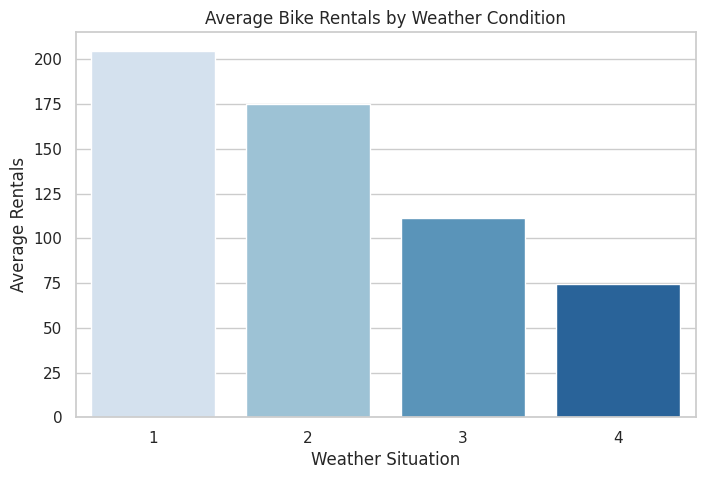

In [21]:
weather = hour_df.groupby("weathersit")["cnt"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=weather,
    x="weathersit",
    y="cnt",
    palette="Blues"
)

plt.title("Average Bike Rentals by Weather Condition")
plt.xlabel("Weather Situation")
plt.ylabel("Average Rentals")

plt.show()

### Pertanyaan 2:

In [22]:
working = hour_df.groupby(
    ["workingday","hr"]
)["cnt"].mean().reset_index()

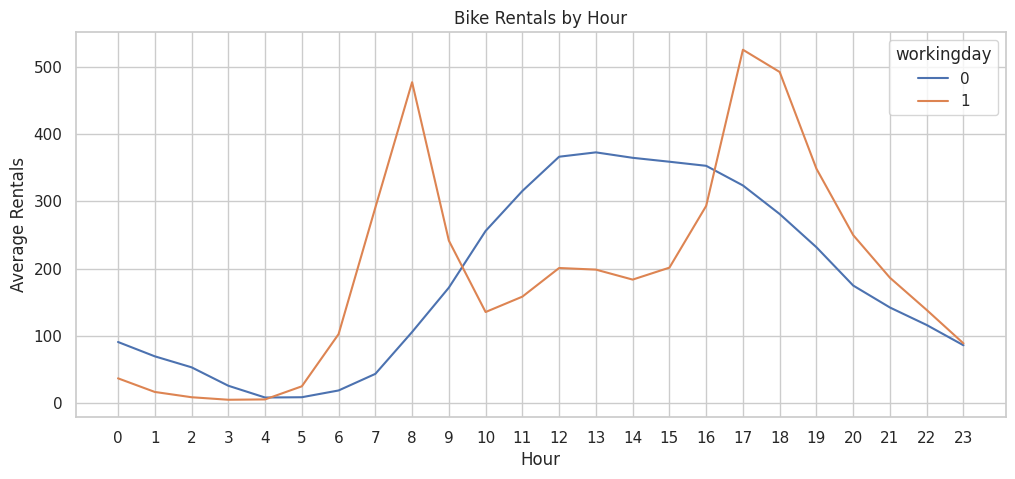

In [23]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=working,
    x="hr",
    y="cnt",
    hue="workingday"
)

plt.xticks(range(24))

plt.xlabel("Hour")

plt.ylabel("Average Rentals")

plt.title("Bike Rentals by Hour")

plt.show()

### Pertanyaan 3:

/tmp/ipykernel_918/3298312500.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=season, x="season", y="cnt", palette="viridis")


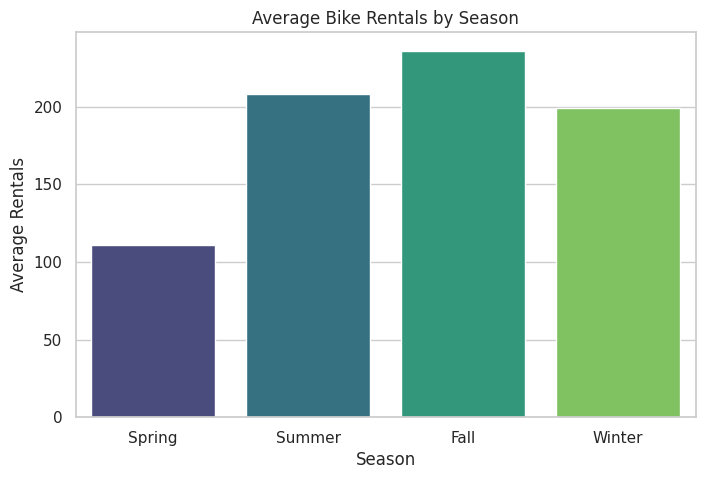

In [24]:
# season = hour_df.groupby("season")["cnt"].mean().reset_index()
season_labels = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

season = hour_df.groupby("season")["cnt"].mean().reset_index()
season["season"] = season["season"].map(season_labels)

plt.figure(figsize=(8,5))
sns.barplot(data=season, x="season", y="cnt", palette="viridis")
plt.title("Average Bike Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Average Rentals")
plt.show()

**Insight:** (Opsional)
- Visualisasi pertama menunjukkan bahwa kondisi cuaca memiliki pengaruh terhadap jumlah penyewaan sepeda. Semakin buruk kondisi cuaca, rata-rata jumlah penyewaan cenderung menurun.
- Visualisasi kedua berdasarkan jam menunjukkan adanya perbedaan pola penyewaan antara hari kerja dan hari libur, terutama pada jam-jam sibuk.
- Visualisasi ketiga menunjukkan rata-rata jumlah penyewaan sepeda berbeda pada setiap musim selama tahun 2011–2012. Musim gugur (season = 3) memiliki rata-rata penyewaan tertinggi, sedangkan musim semi (season = 1) memiliki rata-rata penyewaan terendah. Hal ini menunjukkan bahwa faktor musim turut memengaruhi tingkat penggunaan layanan penyewaan sepeda.

## Analisis Lanjutan (Opsional)

In [25]:
# Manual Clustering berdasarkan waktu

def categorize_hour(hr):
    if 0 <= hr <= 5:
        return "Early Morning"
    elif 6 <= hr <= 11:
        return "Morning"
    elif 12 <= hr <= 17:
        return "Afternoon"
    else:
        return "Evening"

hour_df["time_category"] = hour_df["hr"].apply(categorize_hour)

time_cluster = (
    hour_df
    .groupby("time_category")["cnt"]
    .mean()
    .reindex(["Early Morning","Morning","Afternoon","Evening"])
    .reset_index()
)

time_cluster

,time_category,cnt
0,Early Morning,24.908559
1,Morning,208.100688
2,Afternoon,295.483886
3,Evening,225.757555


/tmp/ipykernel_918/2345838056.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


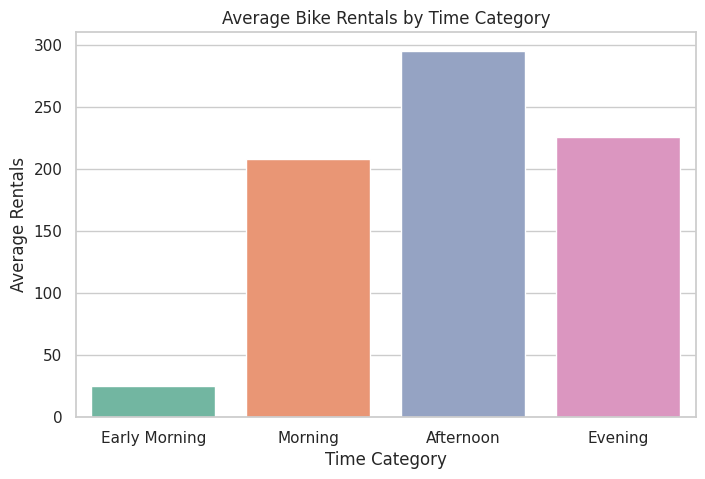

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=time_cluster,
    x="time_category",
    y="cnt",
    palette="Set2"
)

plt.title("Average Bike Rentals by Time Category")
plt.xlabel("Time Category")
plt.ylabel("Average Rentals")

plt.show()

**Insight:** (Opsional)
- Hasil manual clustering menunjukkan bahwa rata-rata jumlah penyewaan sepeda berbeda pada setiap kategori waktu.
- Kategori Afternoon memiliki rata-rata penyewaan tertinggi (295,48), diikuti oleh Evening (225,76) dan Morning (208,10). Sementara itu, kategori Early Morning memiliki rata-rata penyewaan terendah (24,91), yang menunjukkan bahwa aktivitas penyewaan masih sangat rendah pada dini hari hingga sebelum pagi.
- Hasil ini menunjukkan bahwa pengelompokan waktu dapat membantu mengidentifikasi periode dengan permintaan tinggi dan rendah, sehingga dapat dimanfaatkan sebagai dasar dalam perencanaan operasional dan distribusi sepeda.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Hasil analisis menunjukkan bahwa kondisi cuaca berpengaruh terhadap jumlah penyewaan sepeda. Cuaca cerah (weathersit = 1) memiliki rata-rata penyewaan tertinggi yaitu sekitar 205 penyewaan per jam. Rata-rata penyewaan kemudian menurun pada kondisi berkabut (175 penyewaan), hujan ringan atau salju ringan (112 penyewaan), hingga cuaca buruk seperti hujan lebat atau salju (74 penyewaan). Hal ini menunjukkan bahwa semakin buruk kondisi cuaca, semakin rendah jumlah penyewaan sepeda.
- **Conclusion pertanyaan 2:** Pola penyewaan sepeda pada hari kerja dan hari libur menunjukkan karakteristik yang berbeda. Pada hari kerja, jumlah penyewaan mencapai puncaknya pada pukul 08.00 (sekitar 477 penyewaan) dan kembali meningkat pada pukul 17.00 (sekitar 525 penyewaan), yang mencerminkan aktivitas masyarakat saat berangkat dan pulang kerja. Sementara itu, pada hari libur, penyewaan meningkat secara bertahap mulai siang hari dan mencapai puncaknya sekitar pukul 13.00 dengan rata-rata sekitar 373 penyewaan, kemudian menurun menjelang malam.
- **Conclusion pertanyaan 3:** Hasil analisis menunjukkan bahwa musim memengaruhi rata-rata jumlah penyewaan sepeda. Musim gugur (season = 3) memiliki rata-rata penyewaan tertinggi, diikuti oleh musim panas (season = 2) dan musim dingin (season = 4). Sementara itu, musim semi (season = 1) memiliki rata-rata penyewaan terendah. Hal ini mengindikasikan bahwa kondisi lingkungan pada musim gugur lebih mendukung aktivitas bersepeda dibandingkan musim lainnya.
- Berdasarkan hasil manual clustering, periode Afternoon merupakan waktu dengan rata-rata penyewaan sepeda tertinggi, sedangkan Early Morning memiliki permintaan terendah. Pengelompokan ini menunjukkan bahwa permintaan penyewaan tidak merata sepanjang hari dan cenderung meningkat pada siang hingga sore hari ketika aktivitas masyarakat lebih tinggi.

**Rekomendasi Action Item:**
- Menambah jumlah sepeda dan memastikan ketersediaannya pada jam sibuk, terutama sekitar pukul 08.00 dan 17.00 pada hari kerja, karena permintaan mencapai titik tertinggi pada waktu tersebut.

- Menyesuaikan strategi operasional berdasarkan kondisi cuaca. Pada hari dengan cuaca cerah, operator dapat meningkatkan ketersediaan sepeda karena permintaan cenderung lebih tinggi. Sebaliknya, pada cuaca buruk, jumlah redistribusi sepeda dapat disesuaikan dengan penurunan permintaan.

- Menyiapkan kapasitas armada yang lebih besar selama musim gugur dan musim panas, karena kedua musim tersebut memiliki rata-rata penyewaan tertinggi. Sebaliknya, pada musim semi yang memiliki permintaan lebih rendah, perusahaan dapat melakukan perawatan sepeda atau menawarkan program promosi untuk meningkatkan penggunaan layanan.